# 01 — Audit qualité des données

**Objectif** : constater l'état du CSV brut et décider comment traiter chaque anomalie, **sans rien imputer**.

Périmètre : dataset complet (100 000 lignes), **avant le split**. Seules des règles fixes (sans statistique apprise) sont appliquées ici : `churn.data.clean.clean()`. Tout ce qui apprend des données (imputation, écrêtage par quantile, encodage) sera fait dans le pipeline sklearn, fold par fold.

> D18 : le test χ² « manquant × churn » (section 2.3) lit la cible ; il est donc calculé sur **`train.parquet` uniquement** (80 000 lignes). Le reste de l'audit ne lit pas la cible et porte sur les 100 000 lignes. Il sert uniquement à justifier des **indicateurs de manquants**, une décision structurelle ; aucune sélection de variables n'est fondée dessus.

Toute la logique est dans `src/churn/data/` (`validate.py`, `clean.py`, `audit.py`) ; ce notebook ne fait qu'appeler ces fonctions et commenter les résultats. Les décisions sont numérotées (D18–D31) dans `docs/decisions.md`.

In [1]:
import pandas as pd

from churn.config import get_config
from churn.data import audit
from churn.data.clean import clean
from churn.data.load import load_raw
from churn.data.split import load_train
from churn.data.validate import coherence_report, schema_failures, UNKNOWN_CODES
from churn.logging_setup import setup_logging
from churn.plots import apply_style, plot_missing_rates, plot_nullity_heatmap

setup_logging()
apply_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)

cfg = get_config()
TARGET, ID = cfg.data.target, cfg.data.id_col
FIG = cfg.paths.figures_dir
df = load_raw()
df.shape

00:44:19 | INFO    | churn.data.load | Données brutes chargées : 100000 lignes x 100 colonnes (telco_churn.csv)


(100000, 100)

## 1. Validation du schéma brut (pandera)

Types, bornes plausibles, modalités autorisées et règles de cohérence strictes. Seuls les échecs sont listés.

In [2]:
raw_failures = schema_failures(df, "raw")
raw_failures

00:44:20 | INFO    | churn.data.validate | Schéma raw : 5 check(s) en échec


,column,check,n_cas,exemples
0,eqpdays,greater_than_or_equal_to(0),133,"[-1.0, -2.0, -3.0, -4.0, -5.0]"
1,eqpdays,"in_range(0, 3650)",133,"[-1.0, -2.0, -3.0, -4.0, -5.0]"
2,totmrc_Mean,greater_than_or_equal_to(0),23,"[-0.08, -0.0825, -0.24, -0.27, -0.2825]"
3,rev_Mean,greater_than_or_equal_to(0),5,"[-0.16, -2.52, -3.73, -5.8625, -6.1675]"
4,avg6rev,greater_than_or_equal_to(0),3,"[-1.0, -2.0]"


**Constat** : le schéma brut ne signale que des **valeurs négatives impossibles** dans 4 colonnes (`eqpdays` : -1 à -5 jours ; `totmrc_Mean`, `rev_Mean`, `avg6rev`). Toutes les modalités catégorielles sont connues et aucune borne n'est dépassée.

**Décision D19** : NaN + indicateur `<col>_was_negative` (règle fixe dans `clean()`). Les `eqpdays` de -1 à -5 jours ressemblent à un décalage de date (terminal activé juste après la date de mesure) ; l'indicateur conserve cette information.

## 2. Valeurs manquantes

### 2.1 Taux par motif

Les colonnes dont le masque de NaN est **strictement identique** sont regroupées : elles décrivent un seul phénomène.

In [3]:
patterns = audit.missing_patterns(df)
patterns

,groupe,colonnes,n_colonnes,n_manquants,pct
0,numbcars,[numbcars],1,49366,49.37
1,dwllsize,[dwllsize],1,38308,38.31
2,HHstatin,[HHstatin],1,37923,37.92
3,ownrent,[ownrent],1,33706,33.71
4,dwlltype,[dwlltype],1,31909,31.91
5,lor,[lor],1,30190,30.19
6,income,[income],1,25436,25.44
7,adults,[adults],1,23019,23.02
8,infobase,[infobase],1,22079,22.08
9,hnd_webcap,[hnd_webcap],1,10189,10.19


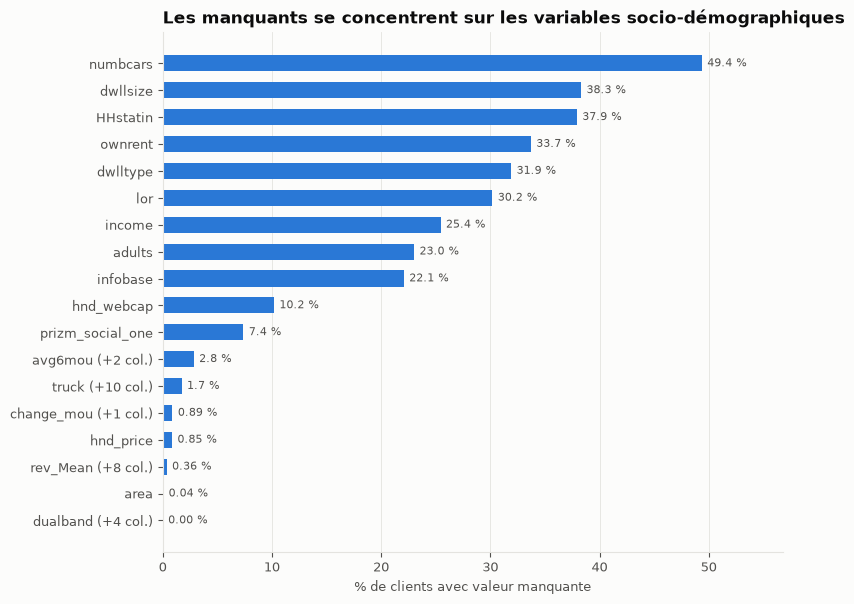

In [4]:
fig = plot_missing_rates(
    patterns,
    "Les manquants se concentrent sur les variables socio-démographiques",
    FIG / "01_missing_rates.png",
)

**Constats**

| Motif | Lecture |
|---|---|
| `numbcars`, `dwllsize`, `HHstatin`, `ownrent`, `dwlltype`, `lor`, `income`, `adults`, `infobase` (22 à 49 %) | Données socio-démographiques achetées à un fournisseur externe : couverture partielle, chacune avec son propre motif. |
| `truck` + 10 colonnes (1,73 %) | Bloc socio-démographique **entièrement** absent : `marital`, `kid*`, `creditcd`, `ethnic`, `rv`, `truck`, `forgntvl`. |
| `avg6*` (2,84 %) | Moyennes sur 6 mois : surtout des clients récents (voir 2.4). |
| `change_mou`, `change_rev` (0,89 %) | Variation d'usage absente pour 891 clients, dont les 357 sans aucune donnée d'usage. Cause non documentée pour les 534 autres. |
| `rev_Mean` + 8 colonnes (0,36 %) | 357 clients **sans aucune donnée d'usage**. |
| `dualband` + 4 colonnes | Une seule ligne sans information terminal. |

**Décision D21** : NaN ≠ « Unknown ». Les NaN restent NaN ici et sont traités dans le pipeline (catégorielles → modalité « Missing », numériques → médiane + indicateur).

### 2.2 Co-occurrence des manquants

Une colonne représentative par motif (hors motifs d'une seule ligne). Corrélation entre les indicateurs « est manquant ».

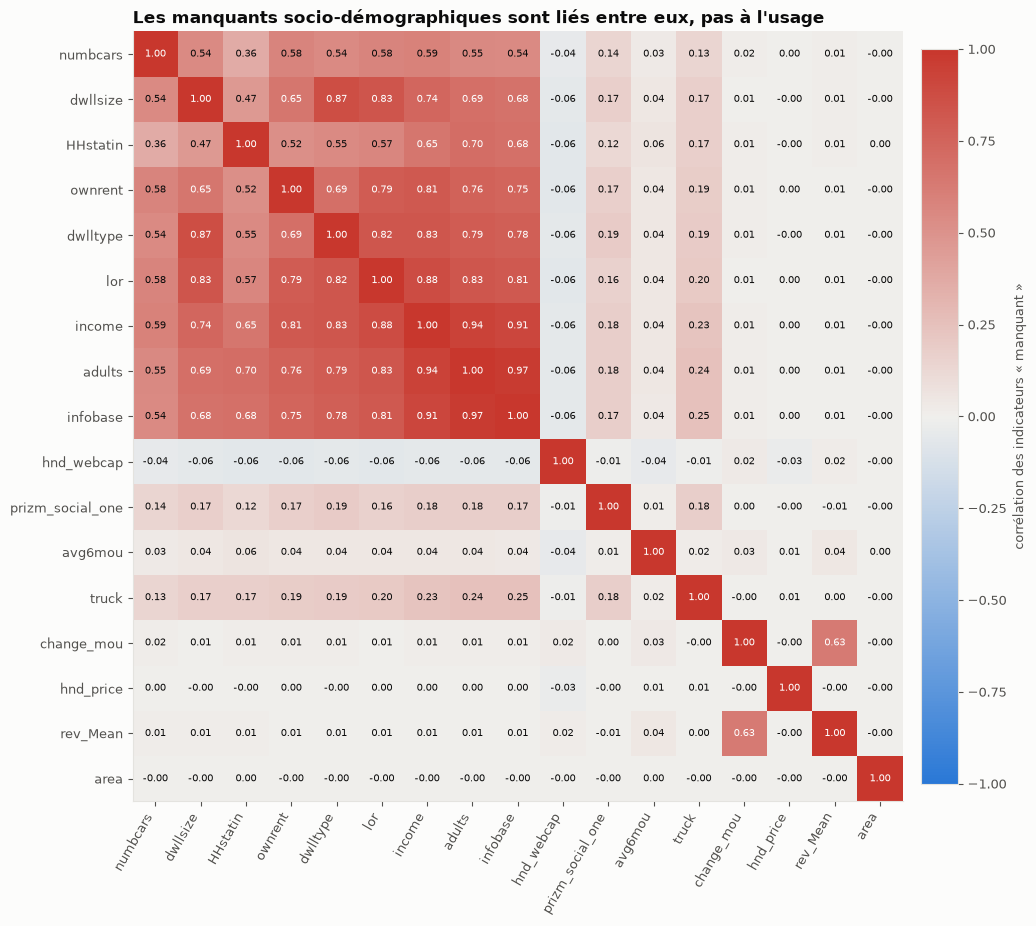

In [5]:
rep = patterns.loc[patterns["n_manquants"] > 1, "groupe"].tolist()
corr = audit.nullity_correlation(df, rep)
fig = plot_nullity_heatmap(
    corr,
    "Les manquants socio-démographiques sont liés entre eux, pas à l'usage",
    FIG / "01_missing_cooccurrence.png",
)

In [6]:
# Paires de motifs les plus liées (hors diagonale)
pairs = corr.where(~pd.DataFrame(
    [[i >= j for j in range(len(corr))] for i in range(len(corr))],
    index=corr.index, columns=corr.columns)).stack()
pairs.sort_values(ascending=False).head(8).round(2)

adults    infobase    0.97
income    adults      0.94
          infobase    0.91
lor       income      0.88
dwllsize  dwlltype    0.87
          lor         0.83
dwlltype  income      0.83
lor       adults      0.83
dtype: float64

**Lecture** : les variables socio-démographiques externes (`dwllsize`, `HHstatin`, `ownrent`, `dwlltype`, `lor`, `income`, `adults`, `infobase`) sont manquantes **ensemble** : c'est la couverture du fournisseur de données, pas un hasard par variable. Le bloc d'usage et `change_*` sont liés (0,63 : les 357 clients sans usage sont inclus dans les 891 sans `change_*`). `avg6*`, `hnd_price`, `hnd_webcap` et `area` sont indépendants des autres motifs (|r| < 0,1).

Conséquence : les manquants ne sont **pas complètement aléatoires** (pas MCAR). Une imputation seule effacerait cette information, d'où les indicateurs (D22).

### 2.3 « Est manquant » × churn : test χ², taille d'effet et correction de Holm

Un test par motif touchant ≥ 0,1 % des lignes. `ethnic` est retirée avant le test (exclue du projet, D4). Calcul sur le **train uniquement** (D18). Avec n = 80 000, presque tout est significatif : on lit d'abord le **V de Cramér** et l'**écart de taux de churn**.

In [7]:
# D18 : train uniquement ; on audite les NaN de la source (pas ceux créés par clean()).
train_audit = audit.source_missingness_view(load_train())
print(f"train : {len(train_audit)} lignes")
chi2 = audit.missing_vs_target(train_audit.drop(columns=["ethnic"]), TARGET, min_pct=0.1)
chi2

train : 80000 lignes


,groupe,n_colonnes,pct_manquant,churn_si_manquant,churn_si_present,ecart_pts,chi2,p_value,cramers_v,p_holm,significatif
0,hnd_webcap,1,10.20,58.9,48.5,10.4,319.6,1.807669e-71,0.0632,2.892270e-70,True
1,change_mou,2,0.90,76.0,49.3,26.7,203.3,4.073720e-46,0.0504,6.110580e-45,True
2,avg6mou,3,2.84,40.0,49.8,-9.8,84.7,3.517586e-20,0.0325,4.924620e-19,True
3,infobase,1,22.12,52.0,48.9,3.2,55.8,8.055356e-14,0.0264,1.047196e-12,True
4,adults,1,23.06,51.8,48.9,2.9,47.2,6.433169e-12,0.0243,7.719803e-11,True
5,lor,1,30.21,51.4,48.8,2.6,46.9,7.432328e-12,0.0242,8.175561e-11,True
6,HHstatin,1,37.99,51.1,48.6,2.4,45.1,1.868583e-11,0.0237,1.868583e-10,True
7,rev_Mean,9,0.37,68.9,49.5,19.5,44.2,2.993253e-11,0.0235,2.693928e-10,True
8,dwllsize,1,38.35,51.0,48.6,2.4,43.1,5.302411e-11,0.0232,4.241929e-10,True
9,income,1,25.46,51.5,48.9,2.6,42.5,7.081727e-11,0.0230,4.957209e-10,True


**Constats**

- Les 16 motifs sont significatifs après Holm. Le bloc socio-démographique (`truck` + 9 colonnes) l'est de justesse (p Holm = 0,039) avec un effet **négligeable** (V = 0,007) ; sur les 100 000 lignes, il ne l'était pas (p = 0,15).
- Les tailles d'effet sont **faibles** (V de Cramér < 0,1 partout), mais certains écarts de taux sont nets :
  - clients sans données d'usage (`rev_Mean` + 8) et sans `change_*` : churn très supérieur à la moyenne ;
  - `hnd_webcap` manquant : churn nettement plus élevé ;
  - `avg6*` et `hnd_price` manquants : churn plus **faible**. Pour `avg6*`, cela reflète l'ancienneté (clients récents, voir 2.4), pas l'absence elle-même.

**Décision D22** : un indicateur de manquant **par motif** (pas par colonne) sera créé en E6 : bloc d'usage, `change_*`, `avg6*`, `hnd_webcap`, `hnd_price`, bloc socio. Les variables socio externes n'en reçoivent pas chacune, car leurs effets sont faibles et redondants ; ce sera testé en CV.

**Décision D24** : les 357 clients sans usage sont **conservés**. Les supprimer retirerait un groupe à fort taux de churn et biaiserait le modèle.

**Décision D32 : risque de fuite liée à la cible.** L'absence totale d'usage (68,9 % de churn sur le train) et l'absence de `change_*` (76,0 %) peuvent traduire un client **déjà parti** au moment de la mesure : c'est alors une conséquence du churn, pas un signe avant-coureur. Hypothèse testée en E8 en comparant le modèle avec et sans ces indicateurs.

### 2.4 `avg6*` manquant : un effet de l'ancienneté

In [8]:
avg6_missing = df["avg6mou"].isna()
df.loc[avg6_missing, "months"].value_counts().sort_index()

months
6     1295
7     1298
8       33
9       16
10       7
11      25
12      12
13      14
14      12
15       8
16       7
17      14
18       4
19       5
20       8
21       6
22       4
23       5
24       3
25       7
26       3
27       5
28       5
29       7
30       4
32       1
33       4
34       3
35       3
36       2
37       3
38       1
39       1
40       2
41       2
43       2
45       1
53       4
56       1
59       1
60       1
Name: count, dtype: int64

**Décision D25** : 2 626 des 2 839 cas (92,5 %) sont des clients de 6 à 8 mois : les moyennes sur 6 mois n'existent pas encore, le manquant est **structurel**. Les 213 cas plus anciens (dont 50 sans aucune donnée d'usage) restent inexpliqués ; ils sont couverts par le même indicateur.

## 3. Doublons

In [9]:
audit.duplicates_summary(df, ID)

{'doublons_id': 0, 'doublons_lignes_hors_id': 0}

**Décision D30** : aucun doublon, aucune action.

## 4. Règles de cohérence

**Strictes** = une violation serait une erreur de données (elles sont intégrées au schéma pandera). **Informatives** = un écart explicable, documenté mais pas corrigé.

In [10]:
coherence = coherence_report(df)
coherence

,regle,description,type,violations,pct
0,actvsubs_le_uniqsubs,abonnements actifs <= abonnements uniques,stricte,0,0.000
1,models_le_phones,modèles distincts <= terminaux,stricte,0,0.000
2,comp_vce_le_plcd_vce,appels voix aboutis <= passés,stricte,0,0.000
3,comp_dat_le_plcd_dat,appels data aboutis <= passés,stricte,0,0.000
4,complete_le_attempt,appels aboutis <= tentés,stricte,0,0.000
5,attempt_eq_plcd,attempt = plcd_vce + plcd_dat,stricte,0,0.000
6,drop_blk_eq_sum,drop_blk = drop_vce + drop_dat + blck_vce + blck_dat,stricte,0,0.000
7,adjmou_le_totmou,minutes ajustées <= minutes totales,stricte,0,0.000
8,adjqty_le_totcalls,appels ajustés <= appels totaux,stricte,0,0.000
9,usage_block_all_or_none,bloc d'usage entièrement présent ou absent,stricte,0,0.000


In [11]:
# Détail des règles informatives violées
over = df.loc[df["adjrev"] > df["totrev"] + 0.01, ["totrev", "adjrev"]]
gap = df["ovrrev_Mean"] - (df["vceovr_Mean"] + df["datovr_Mean"])
print(f"adjrev - totrev : médiane {(over.adjrev - over.totrev).median():.2f}, max {(over.adjrev - over.totrev).max():.2f}")
print(f"ovrrev - (vceovr + datovr), si |écart| > 0,01 : médiane {gap[gap.abs() > 0.01].median():.2f}, max {gap.max():.2f}, min {gap.min():.2f}")
print(f"actvsubs = 0 : {(df.actvsubs == 0).sum()} clients")
ratio = df["eqpdays"] / (df["months"] * 30.4)
print(f"eqpdays / ancienneté (j) : q99 = {ratio.quantile(0.99):.2f}, max = {ratio.max():.2f}")

adjrev - totrev : médiane 4.00, max 51.66
ovrrev - (vceovr + datovr), si |écart| > 0,01 : médiane 0.47, max 42.60, min -0.00
actvsubs = 0 : 81 clients
eqpdays / ancienneté (j) : q99 = 1.05, max = 1.07


**Décisions**

- **D26** : les 10 règles strictes ont **0 violation**. Elles restent dans le schéma comme garde-fou : un fichier futur qui les viole sera rejeté.
- **D27** : `adjrev > totrev` et `ovrrev ≠ vceovr + datovr` ne sont **pas corrigées**. Ce sont probablement des ajustements de facturation et d'autres types de dépassement ; aucune erreur n'est démontrée. La redondance entre ces colonnes sera traitée en E6.
- **D28** : `eqpdays > ancienneté` (terminal acheté avant l'abonnement, ratio max ≈ 1,1) et `actvsubs = 0` (compte sans ligne active au moment de la mesure) sont **conservés** : ce sont des situations plausibles.

## 5. Outliers : quantile 99,9 % et règle IQR

Principales variables de revenu, d'usage, de service et de compte. `max_sur_q999` mesure l'isolement du maximum ; `pct_hors_tukey` est la part hors [Q1 − 1,5·IQR ; Q3 + 1,5·IQR].

In [12]:
OUTLIER_COLS = [
    "rev_Mean", "totmrc_Mean", "ovrrev_Mean", "roam_Mean", "totrev", "avgrev",
    "mou_Mean", "ovrmou_Mean", "totmou", "change_mou", "change_rev",
    "custcare_Mean", "drop_vce_Mean", "uniqsubs", "eqpdays", "hnd_price", "months",
]
outliers = audit.outlier_summary(df, OUTLIER_COLS)
outliers

,min,q25,mediane,q75,q999,max,max_sur_q999,n_sup_q999,pct_hors_tukey,asymetrie
variable,,,,,,,,,,
rev_Mean,-6.167500,33.260000,48.19500,70.750000,450.860140,3843.262500,8.5,100,6.00,9.2
totmrc_Mean,-26.915000,30.000000,44.99000,59.990000,199.990000,409.990000,2.1,87,1.81,1.6
ovrrev_Mean,0.000000,0.000000,1.00000,14.437500,313.437500,1102.400000,3.5,99,11.36,6.2
roam_Mean,0.000000,0.000000,0.00000,0.235000,89.613825,3685.200000,41.1,100,18.98,168.8
totrev,3.650000,518.980000,804.53000,1263.767500,7918.670420,27321.500000,3.5,100,5.68,3.8
avgrev,0.480000,35.370000,49.89000,69.480000,326.020370,924.270000,2.8,100,5.31,3.2
mou_Mean,0.000000,150.750000,355.50000,703.000000,3765.000000,12206.750000,3.2,99,5.17,2.3
ovrmou_Mean,0.000000,0.000000,2.75000,42.000000,1058.274500,4320.750000,4.1,100,11.57,7.4
totmou,0.000000,2529.000000,5191.50000,9776.000000,87989.885953,233419.096700,2.7,100,5.99,4.4


**Lecture**

- La règle de Tukey marque 5 à 26 % des clients sur les variables d'usage. Ce n'est pas une anomalie : ces distributions ont des **queues lourdes** (asymétrie de 2 à 170), et l'IQR n'est pas adapté à ce type de distribution.
- Quelques maxima sont **isolés** (`roam_Mean` ×41 le q99,9, `change_rev` ×33, `uniqsubs` = 196 soit ×28, `change_mou` ×20). Ce sont des comportements extrêmes mais possibles (grand itinérant, compte multi-lignes).

**Décision D29** : aucune suppression et aucun écrêtage dans `clean()`. Un écrêtage par quantile **apprend** un seuil sur les données : il ira donc dans le pipeline (fold par fold) si un modèle linéaire en a besoin (`log1p`, `QuantileTransformer` ou écrêtage). Les modèles à base d'arbres y sont insensibles.

## 6. Nettoyage par règles fixes : `clean()`

Négatifs → NaN + indicateur (D19), code « inconnu » propre à chaque colonne → `Unknown` (D20), typage `category` avec une liste de modalités fixe.

In [13]:
df_clean = clean(df)
print(df_clean.shape)
print("Codes remplacés par 'Unknown' :", UNKNOWN_CODES)
before_after = pd.DataFrame({
    col: {
        "brut": df[col].value_counts(dropna=False).to_dict(),
        "nettoyé": df_clean[col].value_counts(dropna=False).to_dict(),
    }
    for col in ["new_cell", "hnd_webcap", "kid0_2", "prizm_social_one"]
}).T
before_after

00:44:28 | INFO    | churn.data.clean | rev_Mean : 5 valeur(s) négative(s) -> NaN


00:44:28 | INFO    | churn.data.clean | totmrc_Mean : 23 valeur(s) négative(s) -> NaN


00:44:28 | INFO    | churn.data.clean | avg6rev : 3 valeur(s) négative(s) -> NaN


00:44:28 | INFO    | churn.data.clean | eqpdays : 133 valeur(s) négative(s) -> NaN


00:44:29 | INFO    | churn.data.clean | Nettoyage terminé : 100000 lignes x 104 colonnes


(100000, 104)
Codes remplacés par 'Unknown' : {'new_cell': 'U', 'dualband': 'U', 'marital': 'U', 'hnd_webcap': 'UNKW', 'kid0_2': 'U', 'kid3_5': 'U', 'kid6_10': 'U', 'kid11_15': 'U', 'kid16_17': 'U'}


,brut,nettoyé
new_cell,"{'U': 66914, 'Y': 19301, 'N': 13785}","{'Unknown': 66914, 'Y': 19301, 'N': 13785}"
hnd_webcap,"{'WCMB': 75733, 'WC': 13843, nan: 10189, 'UNKW': 235}","{'WCMB': 75733, 'WC': 13843, nan: 10189, 'Unknown': 235}"
kid0_2,"{'U': 94256, 'Y': 4012, nan: 1732}","{'Unknown': 94256, 'Y': 4012, nan: 1732}"
prizm_social_one,"{'S': 32097, 'U': 23613, 'C': 17018, 'T': 14989, nan: 7388, 'R': 4895}","{'S': 32097, 'U': 23613, 'C': 17018, 'T': 14989, nan: 7388, 'R': 4895}"


In [14]:
flags = [c for c in df_clean.columns if c.endswith("_was_negative")]
df_clean[flags].sum()

rev_Mean_was_negative         5
totmrc_Mean_was_negative     23
avg6rev_was_negative          3
eqpdays_was_negative        133
dtype: int64

In [15]:
clean_failures = schema_failures(df_clean, "clean")
print("Échecs du schéma 'clean' :", len(clean_failures))
print(coherence_report(df_clean)[["regle", "type", "violations"]].to_string(index=False))

00:44:30 | INFO    | churn.data.validate | Schéma clean : données conformes


Échecs du schéma 'clean' : 0
                  regle        type  violations
   actvsubs_le_uniqsubs     stricte           0
       models_le_phones     stricte           0
   comp_vce_le_plcd_vce     stricte           0
   comp_dat_le_plcd_dat     stricte           0
    complete_le_attempt     stricte           0
        attempt_eq_plcd     stricte           0
        drop_blk_eq_sum     stricte           0
       adjmou_le_totmou     stricte           0
     adjqty_le_totcalls     stricte           0
usage_block_all_or_none     stricte           0
       adjrev_le_totrev informative          48
      ovrrev_eq_vce_dat informative         187
      eqpdays_le_tenure informative        5145
          actvsubs_ge_1 informative          81


**Constats** :

- `prizm_social_one` garde sa modalité `U`, qui signifie *Urban* et non *unknown*.
- `kid*` passe de Y/U à Y/Unknown : `U` n'y voulait pas dire « non », puisque la modalité N n'existe jamais.
- Les 164 valeurs négatives sont devenues NaN avec leur indicateur.
- Le jeu nettoyé passe le schéma `clean` sans aucun échec.

`clean()` sera appliquée dans `make data` (E3), avant le split.

## 7. Rapport récapitulatif

In [16]:
neg = raw_failures[raw_failures["check"].str.startswith("greater_than")].set_index("column")["n_cas"]
chi2_view = chi2[["groupe", "n_colonnes", "pct_manquant", "churn_si_manquant", "churn_si_present",
                  "ecart_pts", "cramers_v", "p_holm", "significatif"]].copy()
chi2_view["p_holm"] = chi2_view["p_holm"].map(lambda p: f"{p:.1e}")
patterns_view = patterns.assign(colonnes=patterns["colonnes"].map(lambda c: ", ".join(c)))

decisions = pd.DataFrame([
    ("Valeurs négatives impossibles", ", ".join(f"{c} ({n})" for c, n in neg.items()), "NaN + indicateur `_was_negative` dans clean()", "D19"),
    ("Code « inconnu » différent selon la colonne", "U : new_cell, dualband, marital, kid* ; UNKW : hnd_webcap", "→ modalité `Unknown` ; prizm_social_one U = Urban conservé", "D20"),
    ("NaN (donnée non collectée)", f"{len(patterns)} motifs, 22 à 49 % sur le socio externe", "Conservés ; imputés dans le pipeline", "D21"),
    ("Manquant lié au churn", f"{int(chi2['significatif'].sum())}/{len(chi2)} motifs significatifs (Holm), V ≤ {chi2['cramers_v'].max():.3f}", "Indicateur par motif en E6", "D22"),
    ("Colonnes > 40 % de NaN", "numbcars (49,4 %)", "Pas de suppression a priori ; tranché en CV (E6)", "D23"),
    ("Clients sans usage", f"{int(df['rev_Mean'].isna().sum())} lignes", "Conservés ; possible fuite « déjà parti » (avec change_* manquants), test avec / sans en E8", "D24, D32"),
    ("avg6* manquant", f"{int(avg6_missing.sum())} clients, dont {(avg6_missing & (df.months <= 8)).mean() / avg6_missing.mean():.1%} à 6-8 mois", "Surtout structurel (clients récents) ; indicateur", "D25"),
    ("Règles de cohérence strictes", "10 règles, 0 violation", "Garde-fou dans le schéma pandera", "D26"),
    ("adjrev > totrev ; ovrrev ≠ vceovr + datovr", f"{coherence.set_index('regle').loc['adjrev_le_totrev','violations']} ; {coherence.set_index('regle').loc['ovrrev_eq_vce_dat','violations']}", "Non corrigé (écart explicable)", "D27"),
    ("eqpdays > ancienneté ; actvsubs = 0", f"{coherence.set_index('regle').loc['eqpdays_le_tenure','violations']} ; {coherence.set_index('regle').loc['actvsubs_ge_1','violations']}", "Conservés (plausibles)", "D28"),
    ("Outliers (queues lourdes)", "Tukey : 0,3 à 26 % ; maxima isolés roam_Mean, change_rev, uniqsubs", "Aucune suppression ; transformation dans le pipeline", "D29"),
    ("Doublons", "0 ID, 0 ligne", "Aucune action", "D30"),
    ("area manquant ; ligne sans terminal", f"{int(df['area'].isna().sum())} ; {int(df['eqpdays'].isna().sum())}", "Conservés ; imputés dans le pipeline", "D31"),
], columns=["Anomalie", "Constat", "Décision", "Réf."])

report = f"""# Rapport qualité des données — Telecom churn

Généré par `notebooks/01_data_audit.ipynb` à partir de `{cfg.raw_path.name}` : {df.shape[0]} lignes × {df.shape[1]} colonnes, avant split.
Cible : churn = 1 pour {df[TARGET].mean():.2%} des clients. Décisions détaillées : `docs/decisions.md`.

## Synthèse des anomalies et décisions

{audit.to_markdown(decisions, index=False)}

## 1. Validation du schéma brut (pandera)

{audit.to_markdown(raw_failures, index=False)}

Après `clean()` : **{len(clean_failures)} échec** du schéma `clean`.

## 2. Valeurs manquantes (motifs de colonnes toujours absentes ensemble)

{audit.to_markdown(patterns_view[["groupe", "n_colonnes", "n_manquants", "pct", "colonnes"]], index=False)}

![Taux de manquants](figures/01_missing_rates.png)

![Co-occurrence des manquants](figures/01_missing_cooccurrence.png)

## 3. « Est manquant » × churn (χ², Holm, V de Cramér) — train uniquement ({len(train_audit)} lignes, D18)

{audit.to_markdown(chi2_view, index=False, floatfmt="{:.4g}")}

Toutes les tailles d'effet sont faibles (V < 0,1) : ces motifs justifient des indicateurs, pas des conclusions causales.

## 4. Cohérence

{audit.to_markdown(coherence, index=False)}

## 5. Outliers

{audit.to_markdown(outliers, floatfmt="{:,.2f}")}

## 6. Doublons

{audit.to_markdown(pd.DataFrame([audit.duplicates_summary(df, ID)]), index=False)}
"""
report_path = cfg.paths.reports_dir / "data_quality_report.md"
report_path.write_text(report, encoding="utf-8")
print(f"Rapport écrit : {report_path} ({len(report.splitlines())} lignes)")

Rapport écrit : C:\Users\malek\OneDrive\Desktop\telecom_churn\reports\data_quality_report.md (131 lignes)
